In [1]:
import numpy as np
import matplotlib.pyplot as plt
from openqaoa.algorithms import QAOA
from openqaoa.problems import MaximumCut
import os
import json
import networkx as nx
import pickle

### Define helper functions

In [2]:
# helper function to produce the cost landscape
def plot_cost_landscape(mixer_angle_iter, cost_angle_iter, variational_params, backend,
                       previous_mixer_angles:list,
                       previous_cost_angles:list):
    """
    This function constructs a 2-D array containing cost values for different pairs
    of parameter values.

    Parameters
    ----------

    """
    cost_landscape = np.zeros((mixer_angle_iter.size,mixer_angle_iter.size),dtype=float)

    for i,mixer_angle in enumerate(mixer_angle_iter):
        for j,cost_angle in enumerate(cost_angle_iter):
            new_variational_params = []
            new_variational_params.extend(previous_mixer_angles)
            new_variational_params.extend([mixer_angle])
            new_variational_params.extend(previous_cost_angles)
            new_variational_params.extend([cost_angle])
            variational_params.update_from_raw(new_variational_params)
            cost_landscape[i,j] = backend.expectation(variational_params)

    return cost_landscape

In [3]:
def read_files(results,problems_directories,bechmarktype_director):    
    # iterate over the problem directories
    for problem_index,problem_dir in enumerate(problems_directories):
        
        # form the complete directory for the current problem
        complete_dir = 'results_cvar_qaoa/'+problem_dir+'/'+bechmarktype_director
    
        # initialize problem substructure
        results[problem_dir] = {}
    
        # iterate over each file in the problem directory
        for filename in os.listdir(complete_dir):
            print(problem_dir,'-',filename,end='\r')
            # guarante that the file is a json and is not evaluating the random initialization
            if filename.endswith('.json') and (not 'rand' in filename) and ('COBYLA' in filename):
                # create the complete filepath and the shortened filename (that is, just showing QAOA hyperparameters + cvar)
                file_path = os.path.join(complete_dir, filename)
                shortened_filename = filename[4:-5]
    
                # open the file
                with open(file_path, 'r', encoding='utf-8') as file:
                    try:
                        # load the file as a dict and get its relevant information
                        jsondata = json.load(file) 
                        #cost_hamiltonian = jsondata['cost_hamiltonian']
                        angles = jsondata['optimized']['angles']
    
                        # update the cost, cost fev number and nfev sumatories, and the min-max values if neccesary
                        results[problem_dir][shortened_filename] = {}
                        #results[problem_dir][shortened_filename]['cost_hamiltonian'] = cost_hamiltonian
                        results[problem_dir][shortened_filename]['angles'] = angles
                        del jsondata
                    except json.JSONDecodeError as e:
                        print(f"Error uploading {file_path}: {e}")
    
    print('-----------------')

### Read files

In [4]:
problems_directories = ['prob0','prob1','prob2','prob3','prob4'] # directorioes for each problem

problems_noiselesscvars = {} # data structure for all the noiselesscvars results

read_files(problems_noiselesscvars,problems_directories,'noiselessCVAR')

-----------------5-standard-rand-xy-COBYLA_noiseless.jsonjsonn


### Define MaxCut problems

In [5]:
graph1 = nx.Graph()
graph1.add_nodes_from([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
graph1.add_edges_from([(0, 6), (0, 8), (1, 5), (2, 7), (2, 8), (3, 5), (3, 7), (4, 8), (6, 7), (7, 9), (8, 9)])

graph2 = nx.Graph()
graph2.add_nodes_from([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
graph2.add_edges_from([(0, 2), (0, 3), (0, 4), (0, 5), (0, 7), (0, 8), (1, 4), (1, 6), (1, 8), (1, 9), (2, 4), (2, 6), (3, 4), (3, 6), (3, 8), (3, 9), (4, 5), (4, 7), (4, 9), (5, 8), (6, 7), (7, 8), (7, 9), (8, 9)])

graph3 = nx.Graph()
graph3.add_nodes_from([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
graph3.add_edges_from([(0, 1), (0, 2), (0, 4), (0, 9), (1, 5), (1, 6), (1, 7), (1, 8), (2, 3), (2, 4), (2, 6), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (4, 5), (4, 7), (4, 8), (5, 6), (5, 7), (5, 8), (5, 9), (6, 8), (6, 9), (7, 8), (7, 9)])

graph4 = nx.Graph()
graph4.add_nodes_from([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
graph4.add_edges_from([(0, 3), (1, 3), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (2, 3), (3, 4), (3, 6), (3, 7), (4, 5), (4, 6), (4, 9), (5, 6), (5, 7), (5, 8), (6, 7), (6, 8), (6, 9), (7, 9), (8, 9)])

graph5 = nx.Graph()
graph5.add_nodes_from([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
graph5.add_edges_from([(0, 5), (0, 7), (0, 8), (1, 2), (1, 3), (1, 4), (1, 6), (1, 9), (2, 3), (2, 4), (2, 5), (2, 8), (2, 9), (3, 5), (3, 6), (3, 7), (3, 9), (4, 6), (4, 7), (4, 9), (5, 6), (6, 7), (6, 8), (7, 9)])

mc1 = MaximumCut(graph1)
mc2 = MaximumCut(graph2)
mc3 = MaximumCut(graph3)
mc4 = MaximumCut(graph4)
mc5 = MaximumCut(graph5)

### Create data structures to iterate

In [6]:
best_cvar_configuration_names = [
    '0.5_p4-standard-ramp-x-COBYLA_noiseless',
    '0.3_p4-standard-ramp-x-COBYLA_noiseless',
    '0.5_p3-standard-ramp-x-COBYLA_noiseless',
    '0.5_p3-standard-ramp-x-COBYLA_noiseless',
    '0.5_p3-standard-ramp-x-COBYLA_noiseless'
]
ps = [4,4,3,3,3]
problemdatas = [problems_noiselesscvars['prob'+str(i)][name] for i,name in zip(range(5),best_cvar_configuration_names)]

#angles_sets =  [problemdatas[i]['angles'] for i in range(5)]
betas_sets = [problemdatas[i]['angles'][len(problemdatas[i]['angles'])//2:] for i in range(5)]
gammas_sets = [problemdatas[i]['angles'][:len(problemdatas[i]['angles'])//2]  for i in range(5)]

mcs = [mc1, mc2, mc3, mc4, mc5]

### Create QAOAs

In [7]:
qaoas = []

for i,(betas,gammas,p,mc) in enumerate(zip(betas_sets,gammas_sets,ps,mcs)):
    qaoas.append([])
    for p_to_evaluate in range(1,p+1):
        params = {"betas":betas[:p_to_evaluate], "gammas":gammas[:p_to_evaluate]}
        qaoa = QAOA()
        qaoa.set_circuit_properties(p=p_to_evaluate, init_type="custom", variational_params_dict=params)
        qaoa.set_classical_optimizer(maxiter=0)
        qaoa.compile(mc.qubo)
        qaoa.optimize()
        qaoas[i].append(qaoa)

In [16]:
# cost landscape for standard parameterization
gammas_space = np.linspace(-np.pi,np.pi,100) # pass to 100 for final plot
betas_space = np.linspace(-np.pi/2,np.pi/2,100) # pass to 100 for final plot

RUN = False
if RUN:
    cost_landscapes = []
 
    for i,qaoas_of_problem in enumerate(qaoas):
        cost_landscapes.append([])
        for max_p,qaoa in enumerate(qaoas_of_problem):  
            #max_p = j+1
            print('on problem',str(i),', max_p = ',max_p,end='\r')
            
            previous_mixer_angles = qaoa.variate_params.betas[:max_p]  if max_p > 0 else []
            previous_cost_angles = qaoa.variate_params.gammas[:max_p] if max_p > 0 else []
    
            cost_landscape = plot_cost_landscape(np.array(betas_space), np.array(gammas_space), qaoa.variate_params, qaoa.backend,
                                                previous_mixer_angles,previous_cost_angles)
            cost_landscapes[i].append(cost_landscape)
else:
    with open('cost_landscapes.pkl', 'rb') as f:
        cost_landscapes = pickle.load(f)

In [12]:
cost_landscapes

[[array([[ 0.00000000e+00,  1.00000000e-12,  1.00000000e-12, ...,
          -1.00000000e-12, -1.00000000e-12,  0.00000000e+00],
         [ 1.00000000e-12, -1.73973828e-01, -3.31773204e-01, ...,
           3.31773204e-01,  1.73973828e-01, -1.00000000e-12],
         [ 1.00000000e-12, -3.45148352e-01, -6.58208054e-01, ...,
           6.58208054e-01,  3.45148352e-01, -1.00000000e-12],
         ...,
         [-1.00000000e-12,  3.45148352e-01,  6.58208054e-01, ...,
          -6.58208054e-01, -3.45148352e-01,  1.00000000e-12],
         [-1.00000000e-12,  1.73973828e-01,  3.31773204e-01, ...,
          -3.31773204e-01, -1.73973828e-01,  1.00000000e-12],
         [ 0.00000000e+00, -1.00000000e-12, -1.00000000e-12, ...,
           1.00000000e-12,  1.00000000e-12,  0.00000000e+00]]),
  array([[ 2.00000000e-12,  2.00000000e-12,  3.00000000e-12, ...,
           1.00000000e-12,  1.00000000e-12,  2.00000000e-12],
         [ 2.00000000e-12, -1.41922529e-01, -2.68186325e-01, ...,
           2.68186325e

PROBLEM 0 FOR LAYER 1


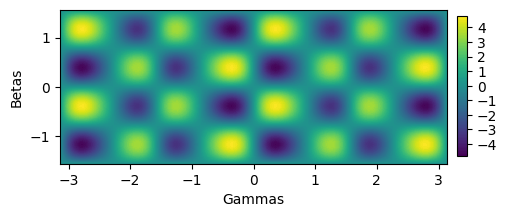

PROBLEM 1 FOR LAYER 1


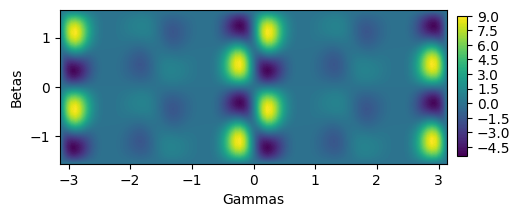

PROBLEM 2 FOR LAYER 1


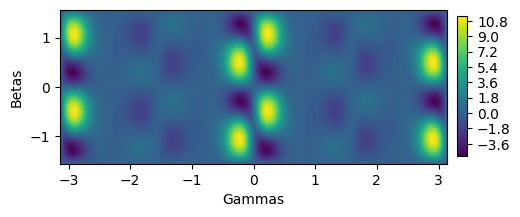

PROBLEM 3 FOR LAYER 1


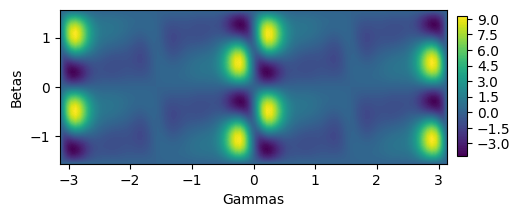

PROBLEM 4 FOR LAYER 1


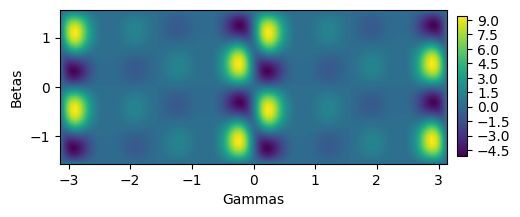

In [22]:
p_to_evaluate = 1 # values 1 to 4
for i,cost_landscape in enumerate(cost_landscapes):
    try:
        print('PROBLEM',i,'FOR LAYER',p_to_evaluate)
        fig, ax = plt.subplots(figsize=(5, 2))
        cmap = 'viridis'

        im = ax.contourf(cost_landscape[p_to_evaluate-1], cmap=cmap, levels=100, extent=(gammas_space[0], gammas_space[-1], betas_space[0], betas_space[-1]))
        #ax.set_title('Cost Landscape for Standard Parameterization')
        ax.set_xlabel('Gammas')
        ax.set_ylabel('Betas')
    
        # Ajuste de la barra de color
        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
        fig.colorbar(im, cax=cbar_ax)
    
        plt.show()
    except Exception as e:
        print(e)
        plt.close()


PROBLEM 1 FOR LAYER 1


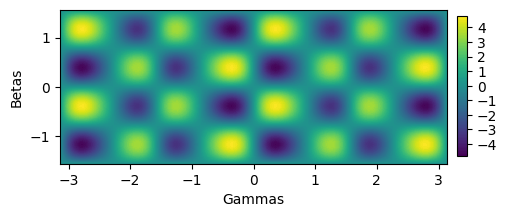

PROBLEM 1 FOR LAYER 2


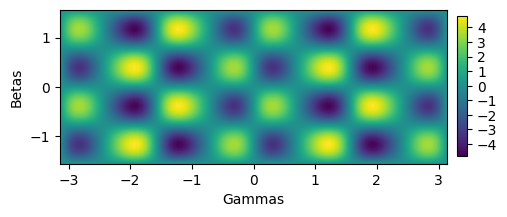

PROBLEM 1 FOR LAYER 3


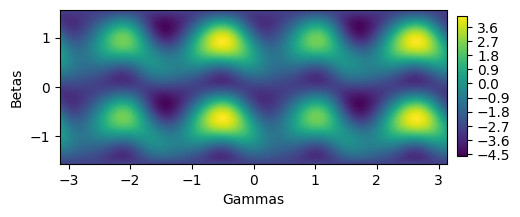

PROBLEM 1 FOR LAYER 4


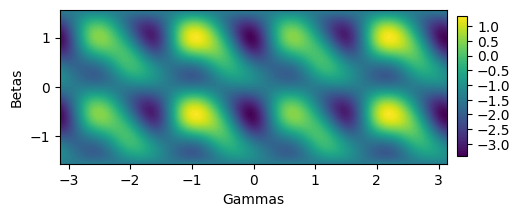

In [21]:
problem_to_evaluate = 1 # values 1 to 5
for i,cost_landscape in enumerate(cost_landscapes[problem_to_evaluate-1]):
    try:
        print('PROBLEM',problem_to_evaluate,'FOR LAYER',i+1)
        fig, ax = plt.subplots(figsize=(5, 2))
        cmap = 'viridis'

        im = ax.contourf(cost_landscape, cmap=cmap, levels=100, extent=(gammas_space[0], gammas_space[-1], betas_space[0], betas_space[-1]))
        #ax.set_title('Cost Landscape for Standard Parameterization')
        ax.set_xlabel('Gammas')
        ax.set_ylabel('Betas')
    
        # Ajuste de la barra de color
        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
        fig.colorbar(im, cax=cbar_ax)
    
        plt.show()
    except:
        plt.close()
